# Tutorial 3: Generating stimuli with known rate and scale

Tutorials 1 and 2 analysed recorded sounds: `wav2aud` turned a waveform into an audiogram, and `aud2cor` decomposed that audiogram into temporal *rates* and spectral *scales*. This tutorial works in the opposite direction, using three helper functions in `neural_audio.utils.mathfuncs` that **build** synthetic signals with a known rate and/or scale:

- `gen_temporal_modulations_rate` — a signal carrying a chosen temporal rate only,
- `gen_spectral_modulations_scale` — a signal carrying a chosen spectral scale only,
- `gen_ripple` — a signal carrying both a chosen rate and scale.

Each returns a 1-D waveform that can be passed straight to `wav2aud`. Because the rate and scale are fixed in advance, these signals are useful for building intuition and for testing: the cortical representation from `aud2cor` should place energy in exactly the rate and scale channels that were requested.

## What rate and scale mean

An audiogram lays out sound energy over two axes: **time** (horizontal) and **frequency** (vertical, log-spaced). Rate and scale describe how that energy is *patterned* along each axis.

- **Rate** (temporal modulation, measured in **Hz**) describes how quickly the energy at a given frequency rises and falls over time. A high rate corresponds to fast fluctuations in level; a low rate to slow ones. The loudness fluctuations of speech, for instance, sit at only a few Hz, whereas a fast flutter or trill has a higher rate.

- **Scale** (spectral modulation, measured in **cycles per octave**, where one octave is a doubling of frequency) describes how finely the energy is patterned across frequency at a single instant. A coarse (low) scale means the energy varies smoothly and broadly across frequency; a fine (high) scale means it alternates between peaks and troughs many times within one octave, as happens for a sound with closely spaced harmonics.

`aud2cor` measures both properties at once, reporting how much each combination of rate and scale contributes to a sound. The functions below produce signals that isolate one or both of these properties, so the resulting audiograms and cortical representations can be read against a known answer.

### Setup

The imports and the rate and scale vectors used throughout are defined once below. As in Tutorial 2, a reduced resolution of 16 rates x 16 scales is used to keep the `aud2cor` computations light.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from neural_audio.wav2aud import wav2aud
from neural_audio.aud2cor import aud2cor
from neural_audio.utils.visualize_outputs import plot_spectrogram, plot_cr_projection
from neural_audio.utils.mathfuncs import (
    gen_temporal_modulations_rate,
    gen_spectral_modulations_scale,
    gen_ripple,
)

# Reduced-resolution rate and scale vectors (16 x 16), as in Tutorial 2.
half_rates  = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)   # temporal rates [Hz]
half_scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)    # spectral scales [cyc/oct]

## Temporal modulation: `gen_temporal_modulations_rate`

`gen_temporal_modulations_rate(rate)` places evenly spaced broadband bursts along the time axis, at `rate` bursts per second. Each burst momentarily contains every frequency, so all frequency channels switch on and off together. The result is a **pure temporal modulation**: structure along time, none across frequency.

The example below uses a rate of about 20 Hz (`half_rates[10]`). In the audiogram this appears as vertical stripes. In the cortical representation the energy concentrates at the matching rate and at the lowest scale, since the spectrum is essentially flat at any given instant (look at the Scale-Rate panel).

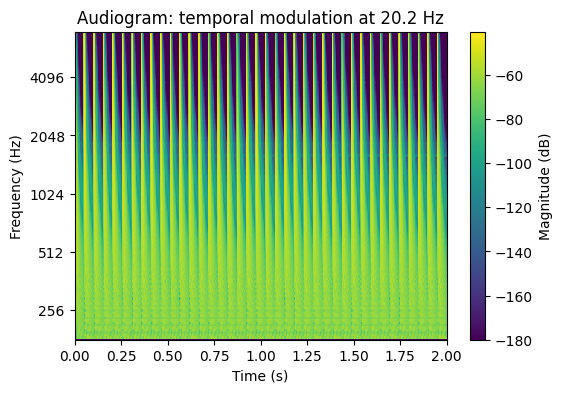

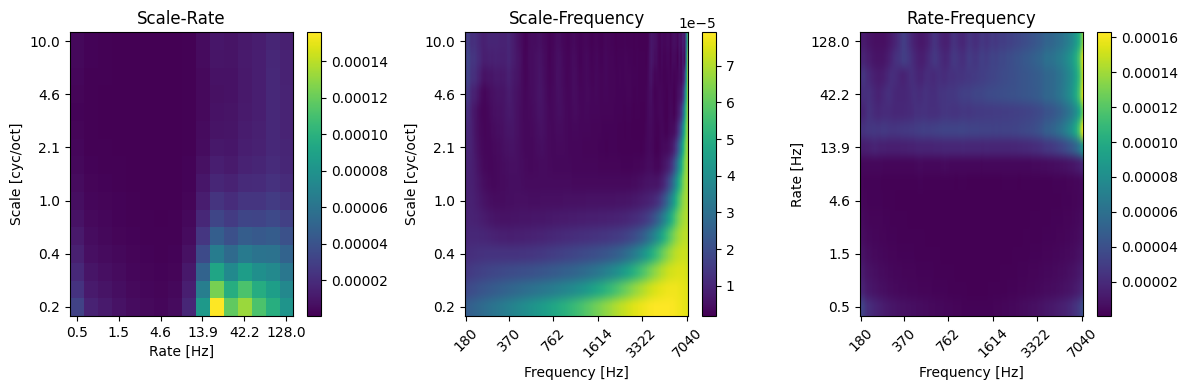

In [4]:
rate = half_rates[10]
waveform = gen_temporal_modulations_rate(rate)

# Audiogram
time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f"Audiogram: temporal modulation at {rate:.1f} Hz")
plt.show()

# Cortical representation (time-averaged projections)
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

## Spectral modulation: `gen_spectral_modulations_scale`

`gen_spectral_modulations_scale(scale)` sums a set of steady tones spaced evenly across log-frequency, with the requested `scale` (in cycles per octave) setting how densely they are packed. The tones do not change over time, so the result is a **pure spectral modulation**: structure across frequency, none along time.

The example below uses a scale of about 2.7 cycles/octave (`half_scales[10]`). In the audiogram this appears as horizontal stripes. In the cortical representation the energy concentrates at the matching scale and at the lowest rate, since nothing changes over time (look at the Scale-Rate panel).

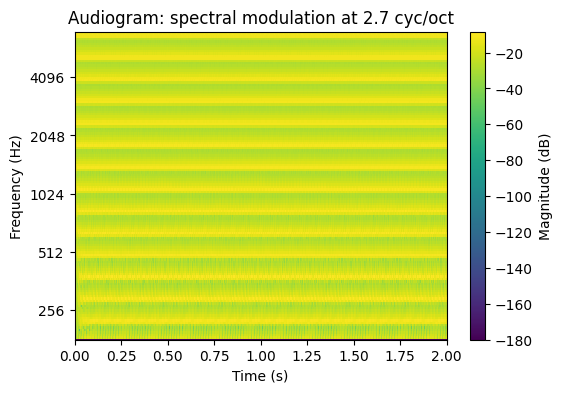

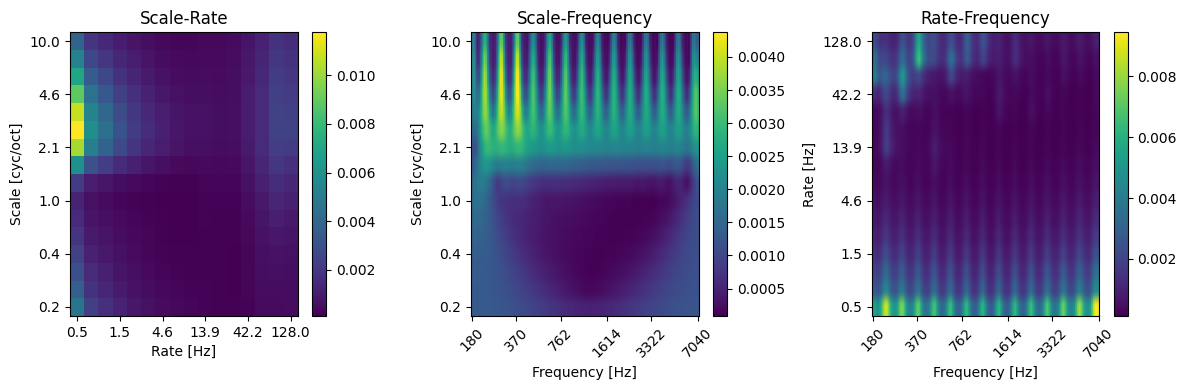

In [5]:
scale = half_scales[10]
waveform = gen_spectral_modulations_scale(scale)

# Audiogram
time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f"Audiogram: spectral modulation at {scale:.1f} cyc/oct")
plt.show()

# Cortical representation (time-averaged projections)
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

## Spectrotemporal ripples: `gen_ripple`

A ripple combines both kinds of modulation. `gen_ripple(rate, scale)` takes a set of steady tones and modulates their amplitudes with a single travelling wave that moves across both time and frequency, following Chi et al. (2005) [[1](#References)]. The `rate` sets how fast the pattern drifts in time and the `scale` sets how densely it repeats across frequency, producing a diagonal ripple in the audiogram.

The example below uses a rate of about 20 Hz and a scale of about 2.7 cycles/octave. In the cortical representation the energy concentrates at that single (rate, scale) pair, which is clearest as a bright spot in the Scale-Rate panel.

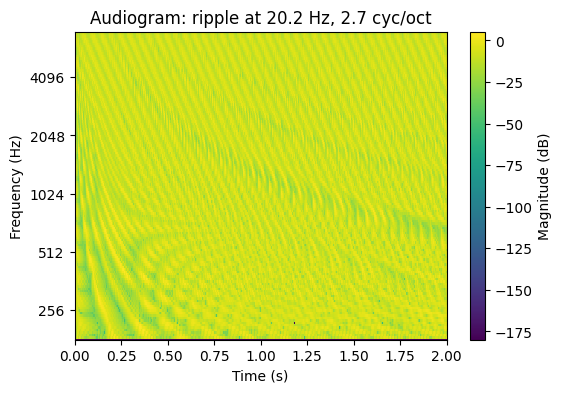

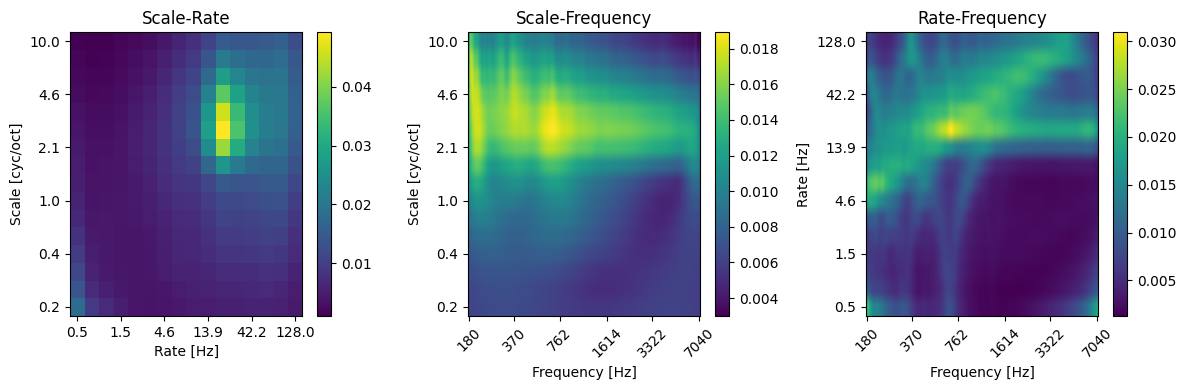

In [6]:
rate = half_rates[10]
scale = half_scales[10]
waveform = gen_ripple(rate=rate, scale=scale)

# Audiogram
time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f"Audiogram: ripple at {rate:.1f} Hz, {scale:.1f} cyc/oct")
plt.show()

# Cortical representation (time-averaged projections)
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds",
        The Journal of the Acoustical Society of America, 118, 887-906,
        10.1121/1.1945807